<a href="https://colab.research.google.com/github/nur079831-dev/Post-test/blob/main/Kategori%20C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

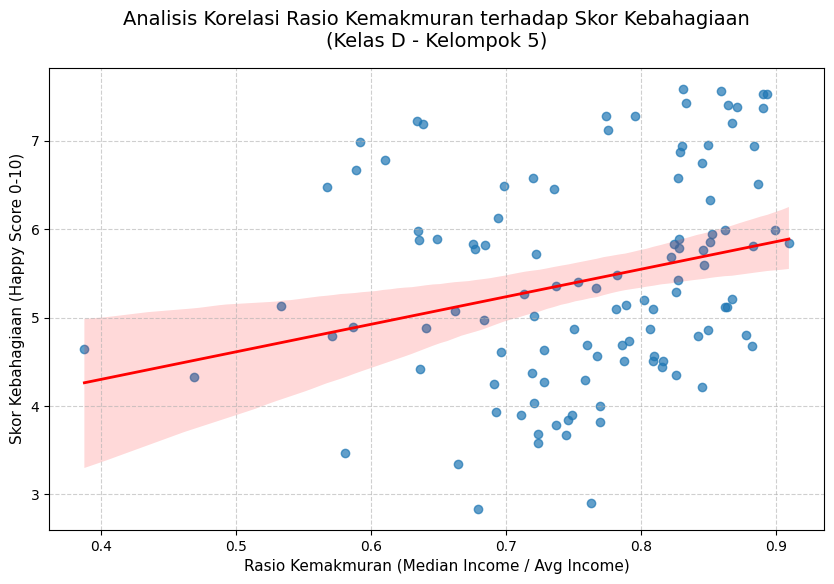

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Membaca dataset dengan penanganan encoding khusus file Excel/CSV Indonesia
# Menambahkan encoding='utf-8-sig' untuk membuang karakter tersembunyi di awal kolom
df = pd.read_csv(
    "Kelas D_Happiness and Satisfaction.csv", delimiter=";", encoding="utf-8-sig"
)

# 2. Membersihkan nama kolom secara total dari spasi tak terlihat atau tanda petik tunggal/ganda
df.columns = (
    df.columns.str.strip()
    .str.replace("'", "", regex=False)
    .str.replace('"', "", regex=False)
)

# 3. Fungsi pembersihan angka desimal yang super aman
def bersihkan_dan_ke_angka(nama_kolom):
    if nama_kolom in df.columns:
        # Ubah data ke string, bersihkan tanda petik/spasi, lalu ubah koma menjadi titik
        df[nama_kolom] = (
            df[nama_kolom]
            .astype(str)
            .str.replace("'", "", regex=False)
            .str.replace('"', "", regex=False)
            .str.strip()
            .str.replace(",", ".", regex=False)
        )
        # Paksa ubah menjadi angka numerik. Jika ada teks yang tersangkut, ubah jadi NaN
        df[nama_kolom] = pd.to_numeric(df[nama_kolom], errors="coerce")


# 4. Ekssekusi pembersihan pada kolom-kolom target yang kita butuhkan
bersihkan_dan_ke_angka("median_income (&)")
bersihkan_dan_ke_angka("avg_income (&)")
bersihkan_dan_ke_angka("Happy Score (0-10)")

# 5. Buang baris yang kosong atau gagal dikonversi agar grafik tidak error
df = df.dropna(subset=["median_income (&)", "avg_income (&)", "Happy Score (0-10)"])

# 6. Hitung Rasio Kemakmuran sesuai instruksi Soal Kategori C
# Rumus: median_income (&) dibagi avg_income (&)
df["Rasio_Kemakmuran"] = df["median_income (&)"] / df["avg_income (&)"]

# 7. Membuat Visualisasi Grafik Scatter Plot
plt.figure(figsize=(10, 6))

# Menggunakan regplot agar otomatis terbentuk scatter plot dengan garis tren korelasi merah
sns.regplot(
    data=df,
    x="Rasio_Kemakmuran",
    y="Happy Score (0-10)",
    scatter_kws={"alpha": 0.7, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2},
)

# Menambahkan elemen grafik formal sesuai standar Asisten Lab Alprog
plt.title(
    "Analisis Korelasi Rasio Kemakmuran terhadap Skor Kebahagiaan\n(Kelas D - Kelompok 5)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Rasio Kemakmuran (Median Income / Avg Income)", fontsize=11)
plt.ylabel("Skor Kebahagiaan (Happy Score 0-10)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)

# Menyimpan grafik ke penyimpanan Google Colab (nanti bisa di-download di folder kiri)
plt.savefig(
    "Korelasi_Rasio_Kemakmuran_vs_Kebahagiaan.png",
    dpi=300,
    bbox_inches="tight",
)

# Tampilkan visualisasi grafik di layar Google Colab
plt.show()